# Dot Products, Matrix Products, and Numpy
**Enter the names of all group members in the cell below**.  If you are submitting this individually, enter your name, along with the names of anyone you worked with while completing these exercises.

John Gilbert Paul IV

## Data Organization

A learning example is comprised of a set of *features* (or *attributes*, or *dimensions*).  In the case where the features are real-valued, each example can be considered a *vector* or a *point*. Let $x$ represent an individual example. Let $d$ be the dimensionality of $x$.  Thus, each example $x$ is a single point where $x \in \mathbb{R}^{d}$.

In Python, example data is typically stored in matrix form.  In ML, this data can be
stored 2 ways, in rows, as shown on the left, and in columns, as is shown on the right.

$\begin{bmatrix}
--        &    x^{(1)}    & -- \\
--        &    x^{(2)}     & -- \\
--         & ...             & -- \\
--         & x^{(m)}    & --   \\
\end{bmatrix}$
or
$\begin{bmatrix}
|            &     |         & |    &   |     \\
x^{(1)}   & x^{(2)}& ... & x^{(m)} \\
|            &     |         & |    &   |     \\
\end{bmatrix}$

**We will usually use the row convention in this course**: $X$ is an $m \times d$ array holding $m$ examples of dimension $d$.

Much of the machine-learning machinery later in this course will boil down to matrix operations.  For example, passing a data matrix $X$ through a three-layer classifier network can be written as

$$ \text{output} = \sigma\!\left(h\!\left(XW^{(1)} \right)W^{(2)} \right). $$

The $W$'s are weight matrices, $h$ is the hidden-layer nonlinearity, and $\sigma$ is the output nonlinearity.  We will develop those ideas later; for now, notice that matrix products do most of the work.

A matrix product combines rows from one array with columns from another.  By the end of this activity, you will have written the same matrix-product computation two ways, first with three loops and then as a table of dot products, and you will have timed both against numpy's built-in matrix-product operator.

## How A Matrix Product Works

**The dot product** of two length-$d$ vectors multiplies them entry by entry and adds up the result, giving a single number:

$$ x \cdot z = \sum_{p=1}^{d} x_{p} z_{p} $$

**The matrix product** $AB$ is a table of dot products.  Entry $(i, j)$ is row $i$ of $A$ dotted with column $j$ of $B$:

$$ (AB)_{ij} = \sum_{p=1}^{d} A_{ip} B_{pj} $$

That row and that column have to be the same length, which is a rule worth memorizing.  The inner dimensions must match, and they cancel:

$$ (m \times d)(d \times k) = (m \times k) $$

So a $2 \times 3$ times a $3 \times 2$ is $2 \times 2$:

$$
\begin{bmatrix} 1 & 2 & 0 \\ 4 & -1 & 3 \end{bmatrix}
\begin{bmatrix} 2 & 1 \\ 0 & -3 \\ 5 & 2 \end{bmatrix}
=
\begin{bmatrix} 2 & -5 \\ 23 & 13 \end{bmatrix}
$$

The lower left entry, for instance, is row 2 of $A$ dotted with column 1 of $B$: $(4)(2) + (-1)(0) + (3)(5) = 23$.

Two consequences:

*   **Order matters.**  Reversing the operands above gives $(3 \times 2)(2 \times 3) = 3 \times 3$, a different matrix of a different shape.  Often only one order is even defined.
*   **The cost is $mdk$ multiplications**, since each of the $mk$ entries needs a length-$d$ dot product.  For two $n \times n$ matrices that is $n^3$, which is why the timing experiments below look the way they do.

### QUESTION

Calculate each of the following **by hand**, on paper, and record your answers in the cell below.

*   $y \cdot z$, where $y = \begin{bmatrix} 2 \\ -4 \\ 1 \end{bmatrix}$ and $z = \begin{bmatrix} 3 \\ 2 \\ -1 \end{bmatrix}$

*   $BA$, where $B = \begin{bmatrix} 1 & 2 & -2 \\ 3 & 0 & 2 \end{bmatrix}$ and $A = \begin{bmatrix} 2 & -1 & 0 \\ 1 & 3 & -2 \\ 0 & 1 & 2 \end{bmatrix}$

Before you multiply anything, write down the *shape* of the result.  Getting into the habit of checking shapes first is a good habit to get into.


1. -3
2. [
    [4  3  -8]
    [6  -1  4]
   ]

---
## PART 1 - Processing Numpy Arrays Using Loops

Until now, you have primarily used *for* loops for performing mathematical operations
on arrays of numbers.  As an example of doing this in Python, you can use a loop to work
with a numpy array:

In [134]:
import numpy as np
np.set_printoptions(precision=3) # Keeps output from getting cluttered.


x = np.random.rand(10)

sum_x = 0

for i in range(x.shape[0]):
    sum_x += x[i]

print(sum_x)

4.47700164281617


## Activity 1

In the cell below, complete the `dot_loop` function using a for loop. You can test your implementation by executing the next cell. (To be clear: using loops is *not* a good idea here.  We'll develop a better implementation later.)

In [135]:
# Write the dot_loop function

def dot_loop(x1, x2):
    """ Returns the dot product of the 1-d numpy arrays x1 and x2 """

    # YOUR CODE HERE
    sum = 0
    for i in range(x1.shape[0]):
        sum += (x1[i] * x2[i])
    return sum

In [136]:
# Tests for the dot_loop function.

import numpy as np

a = np.array([1.0, 2.0, 3.0])
b = np.array([-1.0, 0.5, 4.0])

np.testing.assert_allclose(dot_loop(a, b), 12.0)
np.testing.assert_allclose(dot_loop(b, a), 12.0)   # the dot product is symmetric
np.testing.assert_allclose(dot_loop(a, a), 14.0)
np.testing.assert_allclose(dot_loop(np.array([1.0, 0.0]),
                                   np.array([0.0, 1.0])), 0.0)  # orthogonal

## Activity 2

Now we will build up to the full matrix product.  Using **three nested for loops**, complete the `matmul_loop` function in the cell below.  It should return the matrix product $AB$.  Do not use any built-in dot-product or matrix-product functions.

Here are some potentially helpful reminders:

In [137]:
# The shape property returns a tuple containing the shape of a numpy array,
# and tuples can be unpacked into separate variables:

A = np.random.random((5, 3))
print(A.shape)

rows, cols = A.shape
print("rows: {}, cols: {}".format(rows, cols))

(5, 3)
rows: 5, cols: 3


In [138]:
# np.zeros creates an array of a given shape filled with zeros.  This is the
# usual way to allocate an array that you are about to fill in element by
# element.  Note the DOUBLE parentheses: the shape is a single tuple argument.

C = np.zeros((2, 3))
print(C)

# Individual entries of a 2-d array are accessed with comma notation.
# Use C[i, j].  Do NOT use C[i][j].

C[1, 2] = 7.0
print(C)

[[0. 0. 0.]
 [0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 7.]]


In [139]:
# ##
# Exercise: Complete matmul_loop
# ##

def matmul_loop(A, B):
    """ Return the matrix product AB using nested for loops.
         Arguments:
          A - An m x d numpy array
          B - A  d x k numpy array
         Returns:
          An m x k numpy array
    """
    # YOUR CODE HERE
    m, d = A.shape
    _, k = B.shape

    C = np.zeros((m, k))

    for Ar in range(m):
        for Bc in range(k):
            currA_row = A[Ar]
            currB_col = B[:, Bc]
            
            curr_sum = 0
            for v in range(d):
                curr_sum += currA_row[v] * currB_col[v]
            C[Ar, Bc] = curr_sum
    return C

# a = np.array([[1, 2, -2], [3, 0, 2]])
# b = np.array([[2, -1, 0], [1, 3, -2], [0, 1, 2]])

# print(matmul_loop(a, b))

Execute the cell below to test your implementation.

In [140]:
# Tests for matmul_loop

B = np.array([[1.0, 2.0, -2.0],
              [3.0, 0.0, 2.0]])

A = np.array([[2.0, -1.0, 0.0],
              [1.0, 3.0, -2.0],
              [0.0, 1.0, 2.0]])

# This is the product you computed by hand above:
expected_BA = np.array([[4.0, 3.0, -8.0],
                        [6.0, -1.0, 4.0]])

np.testing.assert_allclose(matmul_loop(B, A), expected_BA)
assert matmul_loop(B, A).shape == (2, 3)

# Non-square shapes need to work too:
expected_ABt = np.array([[0.0, 6.0],
                         [11.0, -1.0],
                         [-2.0, 4.0]])

np.testing.assert_allclose(matmul_loop(A, B.T), expected_ABt)

# A matrix times a single column vector:
y = np.array([[2.0], [-4.0], [1.0]])
np.testing.assert_allclose(matmul_loop(A, y), np.array([[8.0], [-12.0], [-2.0]]))

---
# PART 2 - Processing Numpy Arrays WITHOUT Loops

Loops in Python are *sllloooowwww*.  The key to writing fast numerical programs in Python is to avoid loops by taking advantage of numpy operators and library calls.

## Activity 3

Complete the `dot` function in the cell below.  The functionality should be exactly the same as `dot_loop`, but your implementation *should not contain any loops* (or list comprehensions).

For this exercise, build the answer out of two pieces: an **elementwise** multiplication, and a **reduction** that adds up the result.  In other words, do not use a built-in dot-product operation yet.  The point right now is to see this two-step pattern, which appears often in NumPy code.

First, make sure you are clear about elementwise multiplication:

In [141]:
# PREDICT BEFORE YOU RUN THIS CELL.  What will the result be?

P = np.array([[1.0, 2.0],
              [3.0, 4.0]])

Q = np.array([[0.0, 1.0],
              [1.0, 0.0]])

# The * operator multiplies corresponding entries.  It does not compute
# a matrix product.
print("P * Q (elementwise):\n{}".format(P * Q))

P * Q (elementwise):
[[0. 2.]
 [3. 0.]]


In [142]:
# np.sum reduces an array to a single number by adding up all of its entries:

print(np.sum(np.array([1.0, 2.0, 3.0])))

6.0


In [143]:
def dot(x1, x2):
    """ Returns the dot product of the 1-d numpy arrays x1 and x2 """
    # Note: This should be a one-liner!
    # YOUR CODE HERE
    return np.sum(x1 * x2)

In [144]:
# Tests for dot

a = np.array([1.0, 2.0, 3.0])
b = np.array([-1.0, 0.5, 4.0])

np.testing.assert_allclose(dot(a, b), 12.0)
np.testing.assert_allclose(dot(b, a), 12.0)
np.testing.assert_allclose(dot(a, a), 14.0)
np.testing.assert_allclose(dot(np.array([1.0, 0.0]),
                              np.array([0.0, 1.0])), 0.0)

In [145]:
# TEST SPEED
dim = 10000 # Try changing this value to see how it impacts the running times.
a = np.random.random(dim)
b = np.random.random(dim)

print('time for dot_loop')
%timeit dot_loop(a, b)

print('--------\n\nTime for dot without loops')
%timeit dot(a, b)

time for dot_loop
1.28 ms ± 9.43 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
--------

Time for dot without loops
5.67 μs ± 84.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


Of course, numpy already has a name for "multiply elementwise and then sum."  Run the cell below to confirm that your `dot` function computes the same thing as `np.dot`.  Continue to use your own `dot` function in Activity 4 so that the structure of a matrix product remains visible.

In [146]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([-1.0, 0.5, 4.0])

print(dot(a, b))
print(np.dot(a, b))

12.0
12.0


## Activity 4

Your `matmul_loop` needed three nested loops, and the innermost one is just computing a dot product.  You now have a loop-free way to do that, so you can delete that loop by calling your own `dot` function.

Complete `matmul_dot` in the cell below.  It should return the same result as `matmul_loop`, but it may contain **exactly two loops**, one over the rows of `A` and one over the columns of `B`.  There should be no loop inside them.

Written this way, the code says exactly what the definition says: entry $(i, j)$ is row $i$ of `A` dotted with column $j$ of `B`.

Advice:

* Allocate the result with `np.zeros` as before.
* Slicing extracts a whole row or column from a 2-d array.  `A[i, :]` is row `i` of `A`, and `B[:, j]` is column `j` of `B`.
* Call your `dot` function on those two slices.

In [147]:
# Slicing can be used to extract a single row or column from a numpy array.
# A[i, :] is a row and A[:, j] is a column.  Both come back as 1-d arrays:

A = np.random.random((5, 3))
print(A)
print("\nrow 0:            {}".format(A[0, :]))
print("middle column:    {}".format(A[:, 1]))

[[0.92  0.703 0.215]
 [0.239 0.399 0.818]
 [0.366 0.34  0.711]
 [0.278 0.23  0.947]
 [0.558 0.309 0.333]]

row 0:            [0.92  0.703 0.215]
middle column:    [0.703 0.399 0.34  0.23  0.309]


In [148]:
def matmul_dot(A, B):
    """ Return the matrix product AB using two loops and your dot function.
         Arguments:
          A - An m x d numpy array
          B - A  d x k numpy array
         Returns:
          An m x k numpy array
    """
    # YOUR CODE HERE
    m, d = A.shape
    _, k = B.shape
    C = np.zeros((m, k))
    
    for Ar in range(m):
        for Bc in range(k):
            currA_row = A[Ar]
            currB_col = B[:, Bc]
            C[Ar, Bc] = dot(currA_row, currB_col)

    return C

In [149]:
# Tests for matmul_dot

B = np.array([[1.0, 2.0, -2.0],
              [3.0, 0.0, 2.0]])

A = np.array([[2.0, -1.0, 0.0],
              [1.0, 3.0, -2.0],
              [0.0, 1.0, 2.0]])

expected_BA = np.array([[4.0, 3.0, -8.0],
                        [6.0, -1.0, 4.0]])

np.testing.assert_allclose(matmul_dot(B, A), expected_BA)
assert matmul_dot(B, A).shape == (2, 3)

expected_ABt = np.array([[0.0, 6.0],
                         [11.0, -1.0],
                         [-2.0, 4.0]])

np.testing.assert_allclose(matmul_dot(A, B.T), expected_ABt)

y = np.array([[2.0], [-4.0], [1.0]])
np.testing.assert_allclose(matmul_dot(A, y), np.array([[8.0], [-12.0], [-2.0]]))

# Your two implementations should agree on arbitrary inputs:
R1 = np.random.random((7, 5))
R2 = np.random.random((5, 4))
np.testing.assert_allclose(matmul_dot(R1, R2), matmul_loop(R1, R2))

## Matrix Products in Numpy

Your `matmul_dot` function makes the structure of a matrix product explicit: it computes one dot product for every row-column pair.  Numpy's `@` operator performs that whole table of dot products at once.  For two-dimensional arrays, `A @ B` means the matrix product $AB$.

There is nothing to write here.  Run the next two cells to confirm that `matmul_dot(A, B)` and `A @ B` agree, and to see how `@` differs from `*`.  Then run the timing cell that follows.


In [150]:
A_small = np.array([[1.0, 2.0, 0.0],
                    [4.0, -1.0, 3.0]])
B_small = np.array([[2.0, 1.0],
                    [0.0, -3.0],
                    [5.0, 2.0]])

print("matmul_dot(A_small, B_small):\n{}".format(matmul_dot(A_small, B_small)))
print("\nA_small @ B_small:\n{}".format(A_small @ B_small))
np.testing.assert_allclose(matmul_dot(A_small, B_small), A_small @ B_small)

matmul_dot(A_small, B_small):
[[ 2. -5.]
 [23. 13.]]

A_small @ B_small:
[[ 2. -5.]
 [23. 13.]]


In [151]:
# Read @ as "matrix product."  It is different from *, which multiplies
# corresponding entries.  For these arrays, both operations are defined,
# but they produce different answers:

P = np.array([[1.0, 2.0],
              [3.0, 4.0]])
Q = np.array([[0.0, 1.0],
              [1.0, 0.0]])

print("P * Q (elementwise):\n{}".format(P * Q))
print("\nP @ Q (matrix product):\n{}".format(P @ Q))

P * Q (elementwise):
[[0. 2.]
 [3. 0.]]

P @ Q (matrix product):
[[2. 1.]
 [4. 3.]]


In [152]:
# TEST SPEED
#
# Both of your implementations are complete, so time them against numpy's
# built-in @ on the same matrices.  matmul_loop uses %time, which runs it
# ONCE.  Using %timeit there would run it repeatedly and make you wait
# much longer.

n = 200
A = np.random.random((n, n))
B = np.random.random((n, n))

print('time for matmul_loop (three loops, one run)')
%time C_slow = matmul_loop(A, B)

print('--------\n\ntime for matmul_dot (two loops)')
%timeit matmul_dot(A, B)

A @ B  # A throwaway call, so we do not time one-time library startup costs.

print('--------\n\ntime for A @ B (no loops)')
%timeit A @ B

time for matmul_loop (three loops, one run)
CPU times: user 983 ms, sys: 9.15 ms, total: 992 ms
Wall time: 994 ms
--------

time for matmul_dot (two loops)
63.1 ms ± 2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
--------

time for A @ B (no loops)
54.9 μs ± 1.05 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### QUESTION

Compare the three timings you collected for the same $200 \times 200$ product.  Deleting the innermost loop produced a real speedup, but deleting the remaining two produced a far larger one.

Here is the key fact you need to explain the difference: every call from Python into numpy has some fixed setup cost, while the array arithmetic inside numpy runs in fast compiled code.  `matmul_dot` makes one numpy `dot` call for every entry of the result, whereas `A @ B` requests the entire product in one call.

Using that fact, explain the timing difference.  Compare the number of Python loop iterations and numpy calls made by each implementation, along with how much arithmetic each call performs.

The major difference between the three ways of calculating the product of the matricies is the number of loop iterations each one is doing. The first function has 3 loops which means for the 200 X 200 product it is doing roughly 8,000,000 calculations in python. The next function, after we got rid of the third for-loop and switched to using numpys' "dot" method, ran significantly faster because it only needed to run 40,000 loops instead of the previous 8,000,000. The final method of calculating the product is to use the "@" symbol, this method is much faster because it only requires 1 call to numpys' wrapper, which uses strategically compiled code to heavily improve the speed of the calculations and reduce as much overhead as possible.

---
# Part 3 - Working With Real Data

The cell below loads a small data set of handwritten digits and displays two of them as images.

Each row of `digits` is one 8x8 image flattened into 64 numbers, so this array follows the $m \times d$ convention from the top of the notebook: 1797 examples, 64 features each.


(1797, 64)
(1797,)


<Figure size 640x480 with 0 Axes>

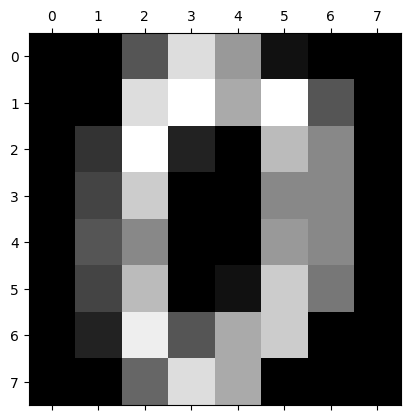

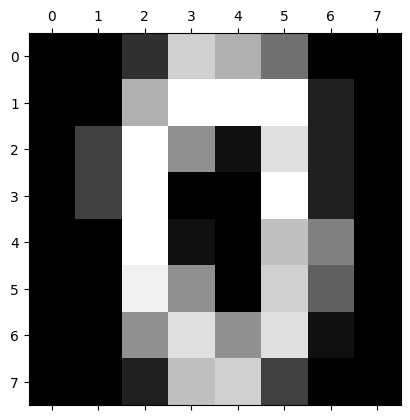

In [153]:
from sklearn.datasets import load_digits
digits, labels = load_digits(return_X_y=True)


print(digits.shape)
print(labels.shape)

# Show the fist and second digits in the data set:
import matplotlib.pyplot as plt
plt.gray()
plt.matshow(digits[0, :].reshape(8, 8)) ## make into a square matrix for matshow
plt.show()
plt.matshow(digits[20, :].reshape(8, 8)) ## make into a square matrix for matshow
plt.show()

## Activity 5 - Broadcasting and Feature Variance

Before building a model it is worth looking at the features themselves.  A feature whose value barely changes from one example to the next carries almost no information.  A feature that varies a great deal is often where the interesting structure lives.

The **variance** of feature $j$ is the average squared distance from that feature's mean:

$$ \mathrm{Var}(j) = \frac{1}{m}\sum_{i=1}^{m} \left( X_{ij} - \bar{X}_j \right)^2 $$

where $\bar{X}_j$ is the mean of column $j$.

Complete `most_variable_feature` below so that it returns the index of the column of `X` with the largest variance.  **Do not use loops, list comprehensions, or `np.var`.**  Build it out of broadcasting, an `axis` argument, and `np.argmax`.

Here are a few useful examples of using numpy that may prove helpful when writing your code.


In [154]:
# "Broadcasting" can be used to apply the same operation across all rows of
# an array.  Here a length-4 array is subtracted from every row of a 3 x 4
# data matrix.

data = np.array([[3.0, 1.0, 7.0, 4.0],
                 [5.0, 9.0, 7.0, 0.0],
                 [1.0, 5.0, 7.0, 2.0]])

col_means = np.mean(data, axis=0)   # one mean per COLUMN, so length 4

print("data shape:      {}".format(data.shape))
print("col_means shape: {}".format(col_means.shape))
print("\ncolumn means: {}".format(col_means))

centered = data - col_means   # Broadcasting!  Shapes are 3x4 and 4

print("\ndata with each column's mean subtracted:\n{}".format(centered))


data shape:      (3, 4)
col_means shape: (4,)

column means: [3. 5. 7. 2.]

data with each column's mean subtracted:
[[ 0. -4.  0.  2.]
 [ 2.  4.  0. -2.]
 [-2.  0.  0.  0.]]


In [155]:
# The axis argument controls which direction an aggregation collapses.

# axis=0 collapses the rows, leaving one number per COLUMN.
print("sum down the columns: {}".format(np.sum(data, axis=0)))

# axis=1 collapses the columns, leaving one number per ROW.
print("sum across the rows:  {}".format(np.sum(data, axis=1)))

# Arithmetic is elementwise, so squaring first and then summing down the
# columns gives the sum of squared deviations for each column:
print("\nsum of squared deviations per column: {}".format(
    np.sum(centered ** 2, axis=0)))


sum down the columns: [ 9. 15. 21.  6.]
sum across the rows:  [15. 21. 15.]

sum of squared deviations per column: [ 8. 32.  0.  8.]


In [156]:
# np.argmax returns the INDEX of the largest entry, not the entry itself.
# When there is a tie it returns the first index that holds the maximum.

example = np.array([12.0, 45.0, 3.0, 45.0])

print("largest value: {}".format(np.max(example)))
print("its index:     {}".format(np.argmax(example)))


largest value: 45.0
its index:     1


In [157]:
def most_variable_feature(X):
    """ Return the index of the feature with the greatest variance.
         Arguments:
          X - An m x d array of m examples with d features each
         Returns:
          The column index of the feature with the largest variance
    """
    # YOUR CODE HERE
    m, _ = X.shape
    X_col_means = np.mean(X, axis=0)
    
    X_mean_sub = X - X_col_means

    X_squared_sum = np.sum(X_mean_sub ** 2, axis=0)

    return np.argmax(X_squared_sum * (1/m))

In [158]:
# Tests for most_variable_feature

# Column 1 spreads the most; column 2 never changes at all.
small = np.array([[2.0, 10.0, 5.0, 1.0],
                  [4.0, 14.0, 5.0, 3.0],
                  [6.0, 18.0, 5.0, 2.0]])
assert most_variable_feature(small) == 1

# Large values are not the same thing as large variance.  Column 0 holds the
# biggest numbers, but column 1 is the one that actually varies.
shifted = np.array([[100.0, 0.0],
                    [101.0, 8.0],
                    [99.0, -8.0]])
assert most_variable_feature(shifted) == 1

# A tie goes to the first such column, which is what np.argmax does.
tied = np.array([[0.0, 0.0],
                 [1.0, 1.0]])
assert most_variable_feature(tied) == 0

# And on the real data set:
assert most_variable_feature(digits) == 42


your answer: 42
np.var:      42

pixels that never vary: [ 0 32 39]


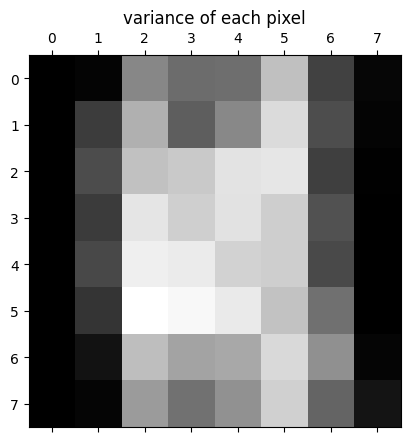

In [159]:
# Of course, numpy already has a name for "average squared distance from the
# mean".  Your function should agree with it:

print("your answer: {}".format(most_variable_feature(digits)))
print("np.var:      {}".format(np.argmax(np.var(digits, axis=0))))

# The per-pixel variance is itself an 8x8 image.  It shows where the pen
# actually goes.  The border pixels barely change, and a few never change at
# all, which means they can tell a classifier nothing.

pixel_variance = np.var(digits, axis=0)
print("\npixels that never vary: {}".format(np.flatnonzero(pixel_variance == 0)))

plt.matshow(pixel_variance.reshape(8, 8))
plt.title("variance of each pixel")
plt.show()


## Activity 6

(Note that this activity is only worth 1 point.  I encourage you to complete it if you have time, but don't stress about it if you need to move on to something else.)

Use numpy masking and slicing to create a smaller data set that contains only the the 1's and 7's from the data set imported above. Store the images in an array named `digits_subset` and the labels in an array named `labels_subset`

Numpy masking provides a fast and convient way of accessing array entries that satisfy logical conditions (see [section 1.4.1.7 Fancy indexing](https://scipy-lectures.org/intro/numpy/array_object.html#using-boolean-masks) in the reading material **scipy lectures** for a brief introduction).  Here is an example:

In [160]:
# Use numpy operators to pull out all columns
# with indices that are multiples of 3 or 7

X = np.random.random((3, 10))
print("X:\n{}".format(X))

all_cols = np.arange(0, X.shape[1])

print("\nAll column indices: {}".format(all_cols))

# Which are multiples of three?
cols_mult_3 = all_cols % 3 == 0

print("\nMultiples of three:")
print(cols_mult_3)

# Which are multiples of seven?
cols_mult_7 = all_cols % 7 == 0

print("\nMultiples of seven:")
print(cols_mult_7)

# We can use logical operators to combine boolean numpy arrays:
col_mask = cols_mult_3 | cols_mult_7

print("\nFinal mask:")
print(col_mask)

X_reduced = X[:, col_mask]

print("\nX_reduced:\n{}".format(X_reduced))

X:
[[0.451 0.292 0.082 0.317 0.004 0.617 0.669 0.4   0.158 0.15 ]
 [0.778 0.888 0.067 0.346 0.88  0.858 0.899 0.94  0.52  0.246]
 [0.361 0.242 0.475 0.967 0.5   0.72  0.055 0.98  0.749 0.981]]

All column indices: [0 1 2 3 4 5 6 7 8 9]

Multiples of three:
[ True False False  True False False  True False False  True]

Multiples of seven:
[ True False False False False False False  True False False]

Final mask:
[ True False False  True False False  True  True False  True]

X_reduced:
[[0.451 0.317 0.669 0.4   0.15 ]
 [0.778 0.346 0.899 0.94  0.246]
 [0.361 0.967 0.055 0.98  0.981]]


In [161]:
# Write code here to initialize the variables digits_subset and labels_subset.

# YOUR CODE HERE
ones_labels = labels == 1
sevens_labels = labels == 7
mask = ones_labels | sevens_labels

digits_subset = digits[mask, :]
labels_subset = labels[mask]

print(digits_subset.shape) # should be (361, 64)
print(labels_subset.shape) # should be (361,)

(361, 64)
(361,)


In [162]:
assert(digits_subset.shape == (361, 64))
assert(labels_subset.shape == (361,))
assert(labels_subset[0] == 1)
assert(labels_subset[-1] == 7)

<Figure size 640x480 with 0 Axes>

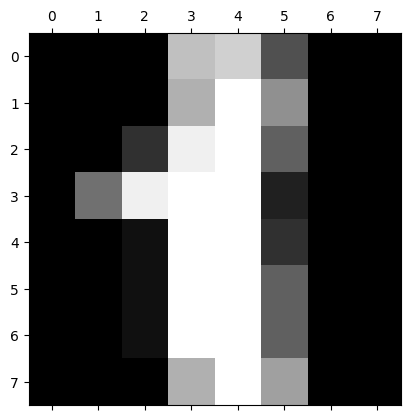

<Figure size 640x480 with 0 Axes>

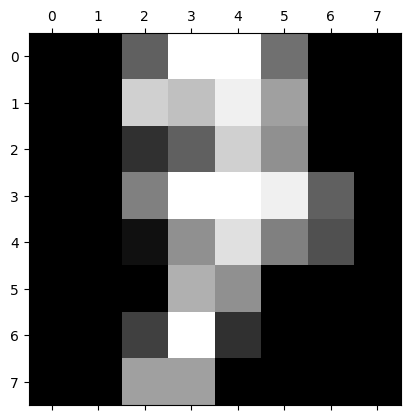

In [163]:
# Look at some of the digits, assuming the variables have been initialized correctly.
plt.gray()
plt.matshow(digits_subset[0, :].reshape(8, 8)) # should be a "1"
plt.figure()
plt.matshow(digits_subset[180, :].reshape(8, 8))  # should be "7"
plt.show()